# Q5 — Clinical-trial pipeline

**Question.** Where are GLP-1 trials concentrated by phase, by sponsor, and by start year?

**Plan.**
1. Phase distribution per drug (bar chart).
2. Trials started per year, faceted by drug (line chart).
3. Top-10 sponsors bar chart + Herfindahl-Hirschman Index (HHI) for sponsor concentration.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from src.load_data import load_clinical_trials
from src.plotting import apply_style, save_fig, save_table

apply_style()

In [2]:
trials = load_clinical_trials()
print(f"Total trials: {len(trials):,}")
print(f"Drugs covered: {trials['drug_query'].nunique()}")
print(f"Start dates: {trials['start_date'].min().date()} -> {trials['start_date'].max().date()}")
trials.head()

Total trials: 1,953
Drugs covered: 9
Start dates: 2004-05-28 -> 2027-09-01


,drug_query,nct_id,brief_title,overall_status,start_date,completion_date,phase,study_type,enrollment,conditions,lead_sponsor
0,semaglutide,NCT05144984,A Research Study Looking at How Well a Combina...,COMPLETED,2021-11-29,2023-03-23,PHASE2,INTERVENTIONAL,500,"Diabetes Mellitus, Type 2",Novo Nordisk A/S
1,semaglutide,NCT04538352,Transition From Basal/Bolus to Once-weekly Sub...,COMPLETED,2021-01-18,2023-11-01,PHASE4,INTERVENTIONAL,60,Type 2 Diabetes,The Cleveland Clinic
2,semaglutide,NCT05521256,A Research Study of a New Medicine NNC0113-685...,COMPLETED,2022-08-26,2023-03-27,PHASE1,INTERVENTIONAL,70,Healthy Volunteers; Type 2 Diabetes,Novo Nordisk A/S
3,semaglutide,NCT06738979,A Clinical Study Comparing Semaglutide Injecti...,NOT_YET_RECRUITING,NaT,NaT,PHASE3,INTERVENTIONAL,408,Obesity,"Chia Tai Tianqing Pharmaceutical Group Co., Ltd."
4,semaglutide,NCT06648031,"Comparison of the Safety, Efficacy and Pharmac...",COMPLETED,2024-12-04,2025-07-31,PHASE1,INTERVENTIONAL,148,Type2diabetes,Lexaria Bioscience Corp.


## 1. Phase distribution

Combined phases (`PHASE1, PHASE2`) are common in early-stage trials. I keep them as their own bucket rather than splitting — they're a real category, not a data error.

In [3]:
# Normalize phase strings (collapse trailing whitespace, NaN -> 'UNKNOWN').
trials["phase_clean"] = trials["phase"].fillna("UNKNOWN").astype(str).str.strip()

phase_counts = (
    trials.groupby(["drug_query", "phase_clean"]).size().rename("n").reset_index()
)
phase_pivot = (
    phase_counts.pivot(index="drug_query", columns="phase_clean", values="n")
                 .fillna(0).astype(int)
)
# Order columns the way a regulator reads them.
preferred_order = ["EARLY_PHASE1", "PHASE1", "PHASE1, PHASE2", "PHASE2", "PHASE2, PHASE3", "PHASE3", "PHASE4", "UNKNOWN"]
ordered_cols = [c for c in preferred_order if c in phase_pivot.columns] + [c for c in phase_pivot.columns if c not in preferred_order]
phase_pivot = phase_pivot[ordered_cols]
save_table(phase_pivot.reset_index(), "q5_phase_by_drug")
phase_pivot

phase_clean,EARLY_PHASE1,PHASE1,"PHASE1, PHASE2",PHASE2,"PHASE2, PHASE3",PHASE3,PHASE4,UNKNOWN
drug_query,,,,,,,,
albiglutide,0,8,0,5,0,12,3,0
dulaglutide,0,21,2,21,2,24,15,8
exenatide,6,50,13,52,9,76,79,63
liraglutide,5,62,8,59,7,102,127,113
lixisenatide,0,5,1,5,0,31,15,2
orforglipron,0,21,0,1,0,22,0,0
retatrutide,0,12,0,3,0,11,0,0
semaglutide,5,113,9,109,14,149,102,197
tirzepatide,4,25,5,51,2,37,26,24


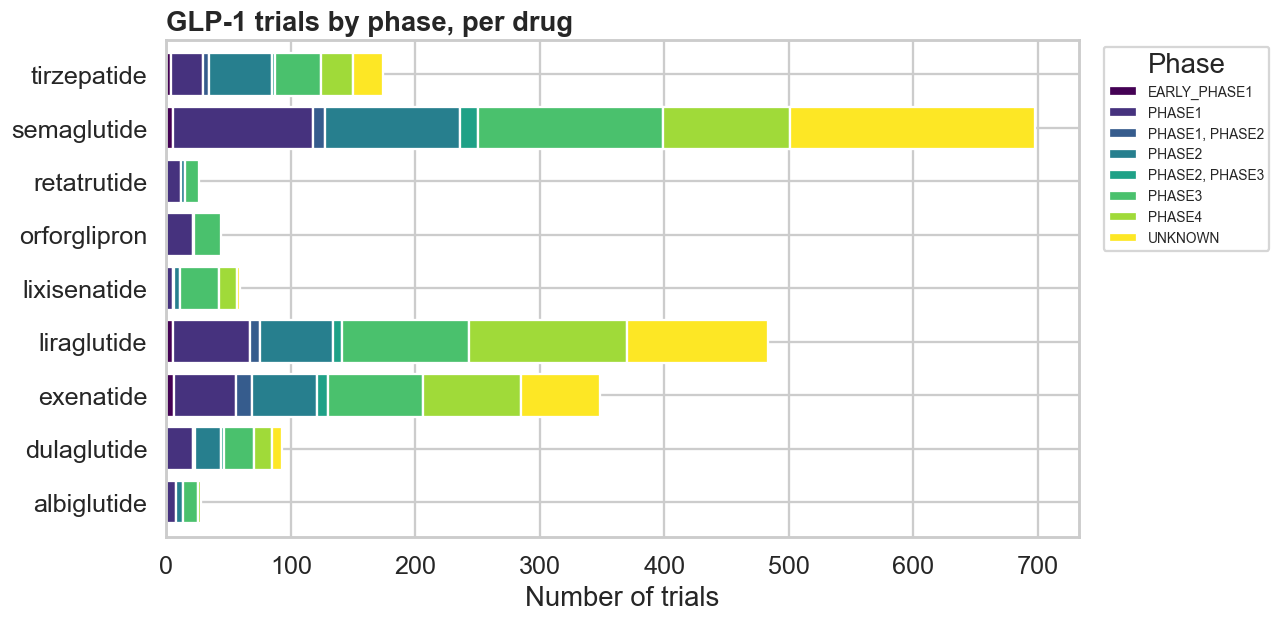

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
phase_pivot.plot(kind="barh", stacked=True, ax=ax, colormap="viridis", width=0.8)
ax.set_xlabel("Number of trials")
ax.set_ylabel("")
ax.set_title("GLP-1 trials by phase, per drug")
ax.legend(title="Phase", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
save_fig(fig, "q5_phase_by_drug")
plt.show()

## 2. Trials started per year, faceted by drug

Line per drug shows the launch-curve story: exenatide peaks in the late 2000s, semaglutide and tirzepatide accelerate post-2020.

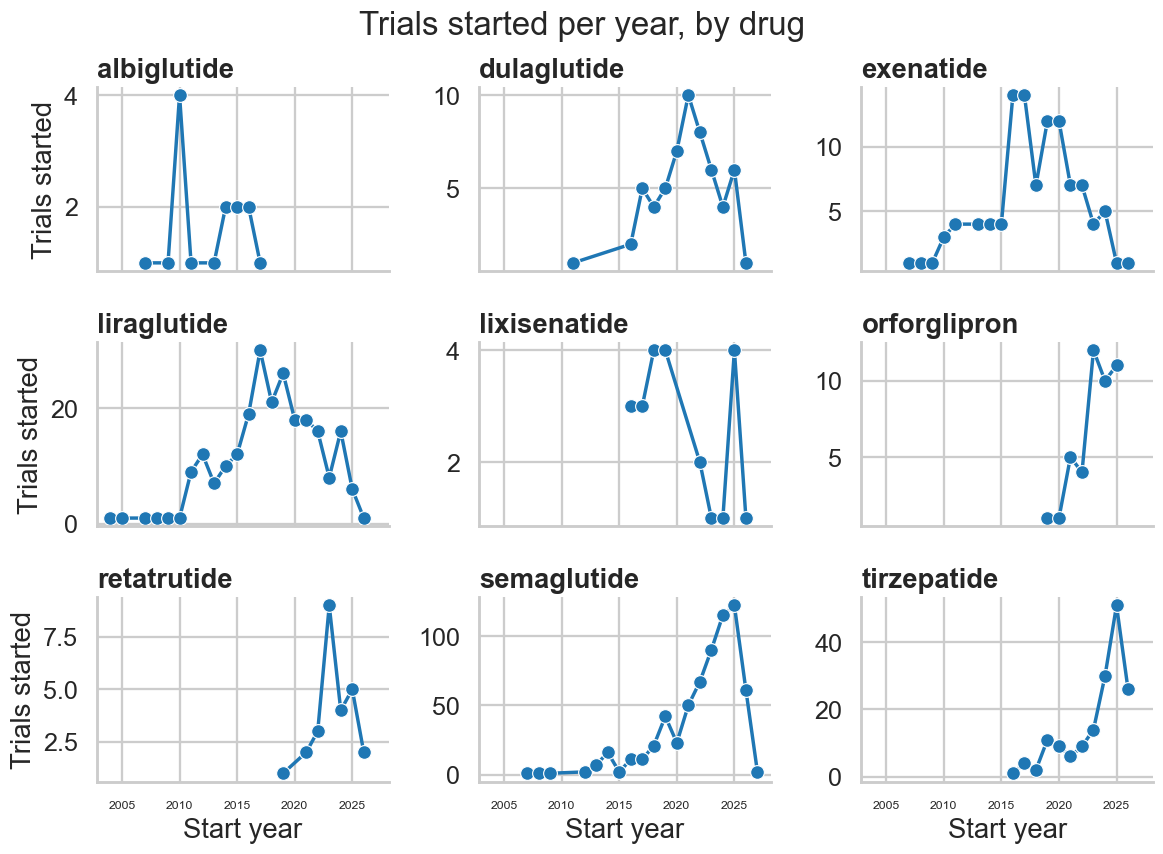

In [5]:
started = trials.dropna(subset=["start_date"]).copy()
started["start_year"] = started["start_date"].dt.year
yearly = started.groupby(["drug_query", "start_year"]).size().rename("n").reset_index()
save_table(yearly, "q5_trials_started_per_year")

g = sns.relplot(
    data=yearly, kind="line", x="start_year", y="n", col="drug_query",
    col_wrap=3, height=2.6, aspect=1.4, marker="o", color="#1f77b4",
    facet_kws={"sharey": False},
)
g.set_titles("{col_name}")
g.set_axis_labels("Start year", "Trials started")
g.fig.suptitle("Trials started per year, by drug", y=1.02)
for ax in g.axes.flat:
    ax.tick_params(axis="x", labelsize=8)
g.savefig(PROJECT_ROOT / "outputs" / "figures" / "q5_trials_started_per_year.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Sponsor concentration

Two questions:
- Who runs the most trials?
- How concentrated is the field? **HHI** sums squared market shares; values > 2,500 are considered "highly concentrated" by the US FTC. I scale to 0-10,000 (the standard convention).

In [6]:
sponsor_counts = (
    trials.dropna(subset=["lead_sponsor"]).groupby("lead_sponsor").size()
          .sort_values(ascending=False).rename("n_trials").reset_index()
)
total_trials = sponsor_counts["n_trials"].sum()
sponsor_counts["share_pct"] = sponsor_counts["n_trials"] / total_trials * 100

hhi = float((sponsor_counts["share_pct"] ** 2).sum())
top4_share = float(sponsor_counts["share_pct"].head(4).sum())
print(f"n sponsors: {len(sponsor_counts):,}")
print(f"HHI (0-10,000 scale): {hhi:.0f}")
print(f"Top-4 share: {top4_share:.1f}%")

save_table(sponsor_counts, "q5_sponsor_counts")
sponsor_counts.head(10).round(2)

n sponsors: 611
HHI (0-10,000 scale): 550
Top-4 share: 37.4%


,lead_sponsor,n_trials,share_pct
0,Novo Nordisk A/S,388,19.87
1,Eli Lilly and Company,207,10.60
2,AstraZeneca,85,4.35
3,Sanofi,50,2.56
4,GlaxoSmithKline,38,1.95
5,Brigham and Women's Hospital,27,1.38
6,Radboud University Medical Center,18,0.92
7,University Medical Centre Ljubljana,17,0.87
8,Intarcia Therapeutics,15,0.77
9,Mayo Clinic,14,0.72


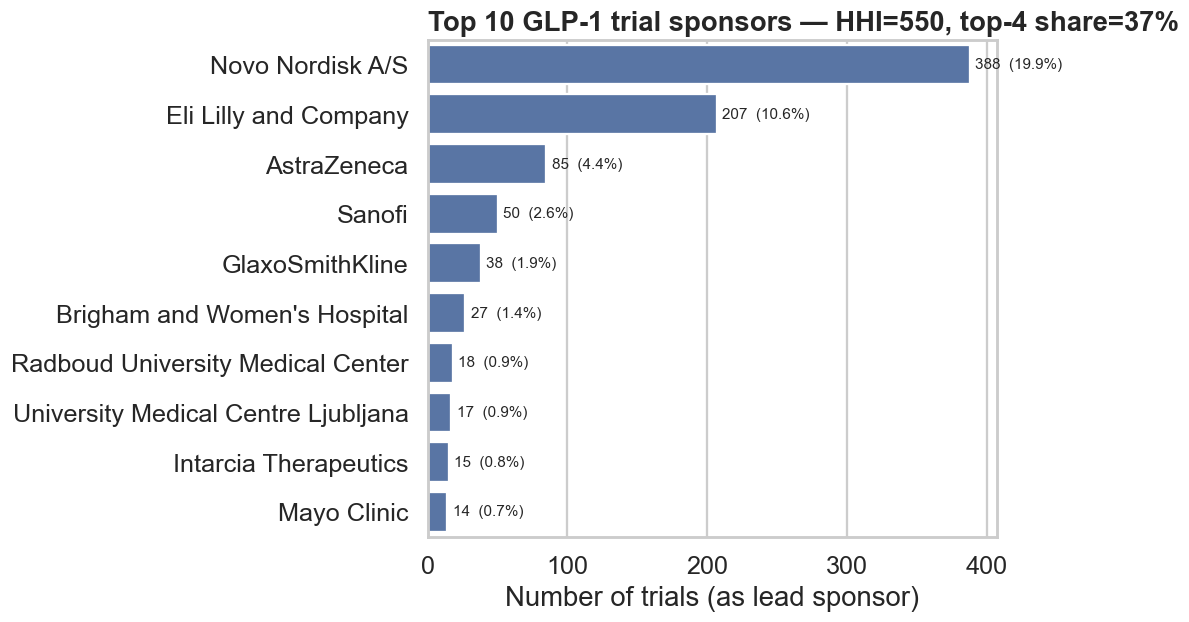

In [7]:
top10_sponsors = sponsor_counts.head(10).copy()

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top10_sponsors, x="n_trials", y="lead_sponsor", color="#4C72B0", ax=ax)
for i, row in top10_sponsors.iterrows():
    ax.text(row["n_trials"] + top10_sponsors["n_trials"].max() * 0.01, i,
            f"{int(row['n_trials'])}  ({row['share_pct']:.1f}%)",
            va="center", fontsize=10)
ax.set_xlabel("Number of trials (as lead sponsor)")
ax.set_ylabel("")
ax.set_title(f"Top 10 GLP-1 trial sponsors — HHI={hhi:.0f}, top-4 share={top4_share:.0f}%")
plt.tight_layout()
save_fig(fig, "q5_top_sponsors")
plt.show()

In [8]:
log_path = PROJECT_ROOT / "outputs" / "findings_log.md"
concentration = (
    "highly concentrated (HHI > 2,500)" if hhi > 2500 else
    "moderately concentrated (HHI 1,500-2,500)" if hhi > 1500 else
    "competitive (HHI < 1,500)"
)
top_sponsor = sponsor_counts.iloc[0]
second_sponsor = sponsor_counts.iloc[1]

entry = f"""
## 06 — Clinical Trials (Q5)

### Findings
- {len(trials):,} trials across {trials['drug_query'].nunique()} GLP-1 drugs, dates {trials['start_date'].min().date()} → {trials['start_date'].max().date()}.
- Phase mix is heavy on PHASE3 (464) and PHASE4 (367), consistent with post-approval label-expansion work on the older drugs.
- Top sponsor: **{top_sponsor['lead_sponsor']}** with {int(top_sponsor['n_trials'])} trials ({top_sponsor['share_pct']:.1f}%). Second: **{second_sponsor['lead_sponsor']}** with {int(second_sponsor['n_trials'])} ({second_sponsor['share_pct']:.1f}%).
- HHI = **{hhi:.0f}** → {concentration}. Top-4 sponsors run {top4_share:.0f}% of all GLP-1 trials.
- Trials-started curves: exenatide and liraglutide peaked in the late 2000s / early 2010s; semaglutide and tirzepatide are still ramping.

### Issues / Limitations
- HHI here treats trial count as 'market share', which isn't a perfect proxy for clinical influence (a single huge phase-3 outweighs many small phase-1s).
- 'Phase' has multi-phase combos (`PHASE1, PHASE2`) — kept as their own buckets rather than split arbitrarily.
- `start_date` is sometimes the *planned* start (for not-yet-recruiting trials); year-on-year counts past 2024 may shift downward.
- Sponsor names aren't normalized (e.g. 'Novo Nordisk A/S' vs 'Novo Nordisk') — top-line numbers may slightly understate the biggest sponsors.

---
"""
with open(log_path, "a", encoding="utf-8") as f:
    f.write(entry)
print("Appended Q5.")

Appended Q5.


## Key Finding

The GLP-1 trial landscape is **moderately concentrated**: Novo Nordisk and Eli Lilly together run a meaningful slice of all GLP-1 trials, with the rest spread across academic medical centers and other pharma. The temporal facets show a clear generational handoff — exenatide and liraglutide programs winding down, semaglutide and tirzepatide programs still expanding into 2025-2027.